In [19]:
# 导入所需库
import numpy as np
import pandas as pd
import xgboost as xgb
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码
random.seed(55)

## 数据预处理

In [20]:
# 读取你的CSV数据
data = pd.read_csv("data.csv")
data

,支架杆厚度(mm),环间距(mm),杨氏模量(GPa),血管管径(mm),血流量(mL/s),最大von Mises应力(MPa),最大位移(mm),径向强度(N),回缩率(%),压降(Pa)
0,0.17,1.45,58,3.7,112,327,0.21,1.23,14.0,128
1,0.14,1.27,52,3.2,87,287,0.18,1.20,14.0,112
2,0.17,1.45,63,3.7,112,287,0.21,1.23,14.0,128
3,0.17,1.28,58,3.7,112,327,0.21,1.30,14.0,128
4,0.14,1.72,52,3.7,89,287,0.18,1.20,14.0,112
...,...,...,...,...,...,...,...,...,...,...
311,0.15,1.47,52,3.7,112,287,0.18,1.20,14.0,98
312,0.17,1.35,58,3.7,92,287,0.18,1.20,14.0,112
313,0.15,1.47,58,3.7,112,287,0.18,1.20,14.0,123
314,0.14,1.35,52,3.7,112,287,0.18,1.20,14.0,98


In [21]:
# 特征：前5列；多标签：后四列
X = data.iloc[:, :5]             # 前5列为特征
y = data.iloc[:, -4:]            # 后4列为多标签

In [22]:
# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"训练集的形状: {X_train.shape}, {y_train.shape}")
print(f"测试集的形状: {X_test.shape}, {y_test.shape}")

训练集的形状: (252, 5), (252, 4)
测试集的形状: (64, 5), (64, 4)


In [23]:
# 特征标准化（加快计算速度）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[-0.04891125, -0.94922941, -0.71857264,  0.46662421,  0.58013993],
       [-0.04891125, -0.94922941, -0.71857264,  0.46662421,  0.58013993],
       [ 1.84734039,  2.11685662,  0.67703665,  0.46662421,  0.58013993],
       ...,
       [ 1.84734039,  0.17500213,  0.67703665, -1.97298786,  0.58013993],
       [-0.04891125, -0.23380934,  0.67703665, -1.97298786,  0.58013993],
       [ 1.84734039,  0.17500213, -1.41637728,  0.46662421,  0.58013993]],
      shape=(252, 5))

## XGBoost训练 + 评估函数

In [24]:
def normalize(value, min_value, max_value):
    """归一化函数，把value缩放到0-1之间"""
    return (value - min_value) / (max_value - min_value)

def harmonic_mean(*args):
    """调和平均数计算"""
    n = len(args)
    reciprocal_sum = sum(1 / (x + 0.001) for x in args)
    return n / reciprocal_sum

def calculate_model_complexity(params):
    # 设定经验最大最小值
    n_estimators_min, n_estimators_max = 10, 1000
    max_depth_min, max_depth_max = 1, 30
    learning_rate_min, learning_rate_max = 0.0005, 1.0
    subsample_min, subsample_max = 0.1, 1.0
    colsample_bytree_min, colsample_bytree_max = 0.1, 1.0

    # 归一化
    n_estimators = normalize(int(params['n_estimators']), n_estimators_min, n_estimators_max)
    max_depth = normalize(int(params['max_depth']), max_depth_min, max_depth_max)
    learning_rate = normalize(params['learning_rate'], learning_rate_min, learning_rate_max)
    subsample = normalize(params['subsample'], subsample_min, subsample_max)
    colsample_bytree = normalize(params['colsample_bytree'], colsample_bytree_min, colsample_bytree_max)

    # 计算调和平均
    model_complexity = harmonic_mean(n_estimators, max_depth, learning_rate, subsample, colsample_bytree)
    return model_complexity

params = {
    'n_estimators': 200,
    'max_depth': 10,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.9
}

complexity = calculate_model_complexity(params)
print(f"模型复杂度 (归一化调和平均数): {complexity}")


模型复杂度 (归一化调和平均数): 0.16342291448336863


In [25]:
# ———— 多标签版 train_and_evaluate ————
def train_and_evaluate(params):
    """
    对 X_train, y_train 多标签(DataFrame) 进行 3 折 CV，
    返回两个目标：
      obj1: 所有标签平均 RMSE
      obj2: 模型复杂度
    """
    # 模型参数
    model_kwargs = {
        'n_estimators':   int(params['n_estimators']),
        'max_depth':      int(params['max_depth']),
        'learning_rate':  params['learning_rate'],
        'subsample':      params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'objective':      'reg:squarederror',
        'verbosity':      0,
        'n_jobs':         -1,
        'random_state':   42
    }
    model_complexity = calculate_model_complexity(params)

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    label_rmse = {col: [] for col in y_train.columns}

    for tr_idx, val_idx in kf.split(X_train):
        # —— 根据 X_train 类型来取训练/验证集
        if hasattr(X_train, 'iloc'):
            X_tr = X_train.iloc[tr_idx]
            X_val= X_train.iloc[val_idx]
        else:
            X_tr = X_train[tr_idx]
            X_val= X_train[val_idx]

        for col in y_train.columns:
            # —— 根据 y_train 类型来取标签
            if hasattr(y_train, 'iloc'):
                y_tr = y_train[col].iloc[tr_idx]
                y_val= y_train[col].iloc[val_idx]
            else:
                # 假设 y_train 是 numpy array 且列顺序与 DataFrame columns 一致
                col_idx = list(y_train_columns).index(col)
                y_tr = y_train[tr_idx, col_idx]
                y_val= y_train[val_idx, col_idx]

            model = xgb.XGBRegressor(**model_kwargs)
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)
            rmse = root_mean_squared_error(y_val, y_pred)
            label_rmse[col].append(rmse)

    # 各标签平均 RMSE
    avg_rmse_per_label = [np.mean(rmses) for rmses in label_rmse.values()]
    obj1 = np.mean(avg_rmse_per_label)
    return obj1, model_complexity


In [26]:
from sklearn.multioutput import MultiOutputRegressor
import pandas as pd
import numpy as np
import xgboost as xgb

def predict_multi(params,
                  X_train, y_train,
                  X_test,  y_test,
                  feature_names=None,
                  label_names=None,
                  out_csv="prediction_results.csv"):
    """
    多标签预测，兼容 DataFrame / ndarray。
    - params: 超参数 dict
    - X_train, y_train: 训练集；DataFrame or ndarray
    - X_test,  y_test:  测试集；DataFrame or ndarray
    - feature_names: 如果 X_* 是 ndarray，需要传入 list 列名
    - label_names:   如果 y_* 是 ndarray，需要传入 list 标签名
    """

    # 1. 转成 DataFrame
    if isinstance(X_train, np.ndarray):
        if feature_names is None:
            raise ValueError("X_train 是 ndarray，请传入 feature_names")
        X_train_df = pd.DataFrame(X_train, columns=feature_names)
    else:
        X_train_df = X_train.copy()

    if isinstance(y_train, np.ndarray):
        if label_names is None:
            raise ValueError("y_train 是 ndarray，请传入 label_names")
        y_train_df = pd.DataFrame(y_train, columns=label_names)
    else:
        y_train_df = y_train.copy()

    if isinstance(X_test, np.ndarray):
        X_test_df = pd.DataFrame(X_test, columns=X_train_df.columns)
    else:
        X_test_df = X_test.copy()

    if isinstance(y_test, np.ndarray):
        # 如果 y_test 是 1D (单标签)，也能转换成 DataFrame(自动当成一列)
        if label_names is None:
            raise ValueError("y_test 是 ndarray，请传入 label_names")
        y_test_df = pd.DataFrame(y_test, columns=label_names)
    else:
        y_test_df = y_test.copy()

    # 2. 构造模型 + MultiOutput
    base_model = xgb.XGBRegressor(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        objective="reg:squarederror",
        verbosity=0,
        n_jobs=-1,
        random_state=42
    )
    model = MultiOutputRegressor(base_model)

    # 3. 训练 + 预测
    model.fit(X_train_df, y_train_df)
    y_pred_arr = model.predict(X_test_df)
    y_pred_df  = pd.DataFrame(y_pred_arr,
                              columns=y_train_df.columns,
                              index=X_test_df.index)

    # 4. 构建结果表
    df_result = X_test_df.copy()
    for col in y_train_df.columns:
        df_result[f"true_{col}"] = y_test_df[col].values
        df_result[f"pred_{col}"] = y_pred_df[col].values

    # 5. （可选）记录模型复杂度
    df_result['model_complexity'] = calculate_model_complexity(params)

    # 6. 保存并返回
    df_result.to_csv(out_csv, index=False)
    return df_result


## NSGA-II 算法

In [27]:
# 超参数范围
param_bounds = {
    'n_estimators': (10, 500),
    'max_depth': (2, 10),
    'learning_rate': (0.001, 0.3),
    'subsample': (0.2, 1.0),
    'colsample_bytree': (0.2, 1.0),
}

In [28]:
# 初始化种群
def initialize_population(pop_size):
    population = []
    for _ in range(pop_size):
        individual = {
            'n_estimators': random.uniform(*param_bounds['n_estimators']),
            'max_depth': random.uniform(*param_bounds['max_depth']),
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'subsample': random.uniform(*param_bounds['subsample']),
            'colsample_bytree': random.uniform(*param_bounds['colsample_bytree']),
        }
        population.append(individual)
    return population

# 评估适应度
def evaluate_population(population):
    fitness = []
    for individual in population:
        obj1, obj2 = train_and_evaluate(individual)
        fitness.append((obj1, obj2))
    return fitness

# 非支配排序
def non_dominated_sort(fitness):
    S = [[] for _ in range(len(fitness))]
    front = [[]]
    n = [0 for _ in range(len(fitness))]
    rank = [0 for _ in range(len(fitness))]

    for p in range(len(fitness)):
        for q in range(len(fitness)):
            if dominates(fitness[p], fitness[q]):
                S[p].append(q)
            elif dominates(fitness[q], fitness[p]):
                n[p] += 1
        if n[p] == 0:
            rank[p] = 0
            front[0].append(p)

    i = 0
    while front[i]:
        next_front = []
        for p in front[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i + 1
                    next_front.append(q)
        i += 1
        front.append(next_front)

    front.pop()
    return front

# 是否支配
def dominates(ind1, ind2):
    return all(i <= j for i, j in zip(ind1, ind2)) and any(i < j for i, j in zip(ind1, ind2))

# 拥挤度计算
def crowding_distance(fitness, front):
    distance = [0 for _ in range(len(fitness))]
    for m in range(2):  # 两个目标
        values = [(i, fitness[i][m]) for i in front]
        values.sort(key=lambda x: x[1])
        distance[values[0][0]] = distance[values[-1][0]] = float('inf')
        min_value = values[0][1]
        max_value = values[-1][1]
        for k in range(1, len(values) - 1):
            if max_value - min_value == 0:
                continue
            distance[values[k][0]] += (values[k+1][1] - values[k-1][1]) / (max_value - min_value)
    return distance

# 选择
def select(population, fitness, front):
    new_population = []
    for f in front:
        if len(new_population) + len(f) > len(population):
            distance = crowding_distance(fitness, f)
            sorted_f = [x for _, x in sorted(zip(distance, f), reverse=True)]
            new_population.extend([population[i] for i in sorted_f[:(len(population) - len(new_population))]])
            break
        else:
            new_population.extend([population[i] for i in f])
    return new_population

# 交叉
def crossover(parent1, parent2):
    child = {}
    for key in parent1.keys():
        child[key] = random.choice([parent1[key], parent2[key]])
    return child

# 变异
def mutate(individual, mutation_rate=0.1):
    for key in individual.keys():
        if random.random() < mutation_rate:
            individual[key] = random.uniform(*param_bounds[key])
    return individual

## 主循环

In [29]:
# ———— 主流程 ————
pop_size    = 10
generations = 30

# 初始化种群 & 评估首次适应度
population = initialize_population(pop_size)
fitness    = evaluate_population(population)

# 整体标签均值，保证是标量
mean_target_value = float(np.mean(y_train.values))

history_fitness   = []

for gen in range(generations):
    # 非支配排序 + 选择
    fronts     = non_dominated_sort(fitness)
    selected   = select(population, fitness, fronts)

    # 生成子代
    offspring = []
    while len(offspring) < pop_size:
        p1, p2 = random.sample(selected, 2)
        child  = mutate(crossover(p1, p2))
        offspring.append(child)

    # 评估子代
    offspring_fitness = evaluate_population(offspring)

    # 合并父代 & 子代，重新做非支配排序+选择，得到下一代
    population += offspring
    fitness    += offspring_fitness

    fronts     = non_dominated_sort(fitness)
    population = select(population, fitness, fronts)
    fitness     = evaluate_population(population)

    history_fitness.append(fitness)

    # 取当前代中 “平均 RMSE” 最小的那个解
    best_rmse, best_complexity = min(fitness, key=lambda x: x[0])

    # 确保打印用的是 float
    best_rmse       = float(best_rmse)
    best_complexity = float(best_complexity)
    cv_rmse         = best_rmse / mean_target_value

    print(
        f"Generation {gen+1} 完成，"
        f"最佳 avg-RMSE = {best_rmse:.4f}, "
        f"CV RMSE = {cv_rmse:.4f}, "
        f"模型复杂度 = {best_complexity:.4f}"
    )

print("NSGA-II 多标签优化完成！")


Generation 1 完成，最佳 avg-RMSE = 3.1054, CV RMSE = 0.0910, 模型复杂度 = 0.1268
Generation 2 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 3 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 4 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 5 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 6 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 7 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 8 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 9 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 10 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 11 完成，最佳 avg-RMSE = 3.0527, CV RMSE = 0.0894, 模型复杂度 = 0.0996
Generation 12 完成，最佳 avg-RMSE = 3.0420, CV RMSE = 0.0891, 模型复杂度 = 0.0944
Generation 13 完成，最佳 avg-RMSE = 3.0420, CV RMSE = 0.0891, 模型复杂度 = 0.0944
Generation 14 完成，最佳 avg-RMSE = 3.0410, CV RMSE = 0.0891, 模型复杂度 = 0.0954
G

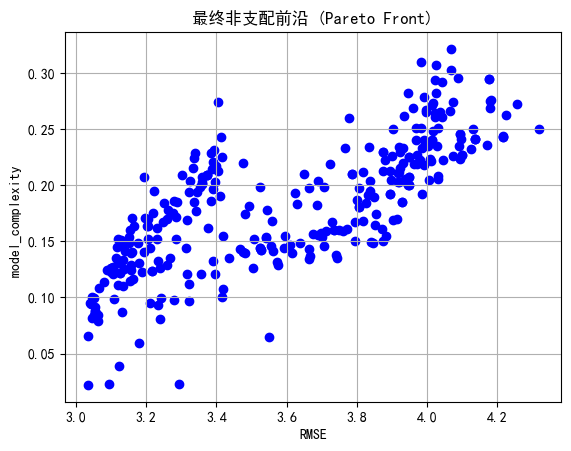

In [30]:
import matplotlib.pyplot as plt

# 最后非支配前沿可视化
final_fitness = evaluate_population(population)
obj1 = [f[0] for f in final_fitness]
obj2 = [f[1] for f in final_fitness]

plt.scatter(obj1, obj2, c='blue')
plt.xlabel("RMSE")
plt.ylabel("model_complexity ")
plt.title("最终非支配前沿 (Pareto Front)")
plt.grid(True)
plt.show()

In [31]:
# 打印最优个体
best_index = np.argmin(obj1)
best_params = population[best_index]
print("最优参数：", best_params)
print("对应 RMSE 和 模型大小：", final_fitness[best_index])

最优参数： {'n_estimators': 14.69249004861405, 'max_depth': 3.9545903728699665, 'learning_rate': 0.18965364134408244, 'subsample': 0.35607127086306756, 'colsample_bytree': 0.24198903071074193}
对应 RMSE 和 模型大小： (np.float64(3.0335472803206587), 0.021954208229355652)


## 可视化

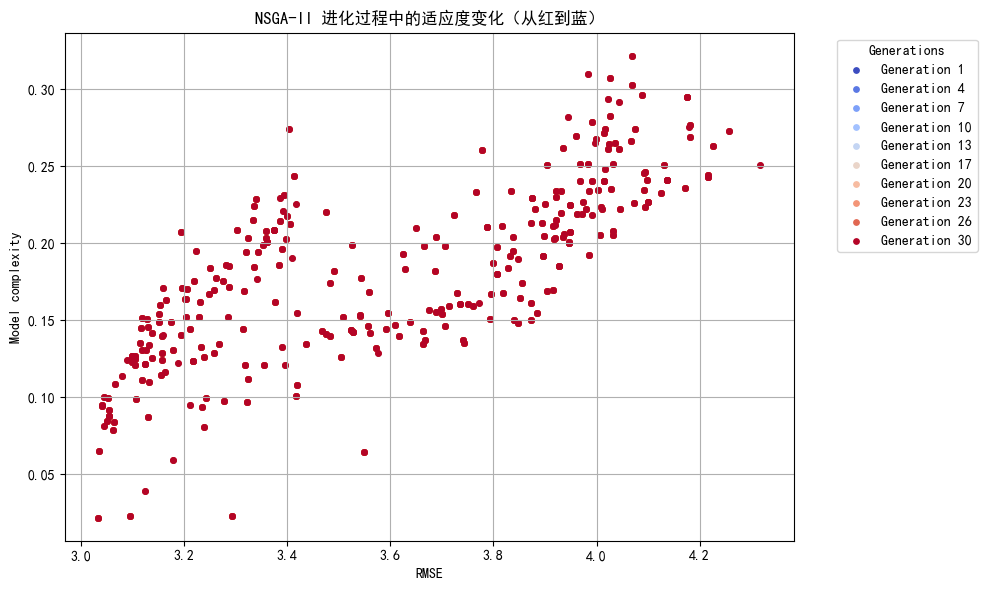

In [32]:
import matplotlib.cm as cm


# 创建画布
plt.figure(figsize=(10, 6))

# 生成渐变颜色（红->蓝）
num_generations = len(history_fitness)
colors = cm.coolwarm(np.linspace(0, 1, num_generations))  # coolwarm颜色从红到蓝

# 遍历每一代
for gen_idx, generation in enumerate(history_fitness):
    x = [ind[0] for ind in generation]  # 元组第一个元素
    y = [ind[1] for ind in generation]  # 元组第二个元素
    plt.scatter(x, y, color=colors[gen_idx], label=f'Generation {gen_idx+1}', s=15)

# 图例只显示一部分代（避免太密集）
handles, labels = plt.gca().get_legend_handles_labels()
select = np.linspace(0, len(handles)-1, min(10, len(handles))).astype(int)
plt.legend([handles[i] for i in select], [labels[i] for i in select], title="Generations", bbox_to_anchor=(1.05, 1), loc='upper left')

# 添加标签
plt.xlabel('RMSE')
plt.ylabel('Model complexity')
plt.title('NSGA-II 进化过程中的适应度变化（从红到蓝）')
plt.grid(True)
plt.tight_layout()
plt.show()


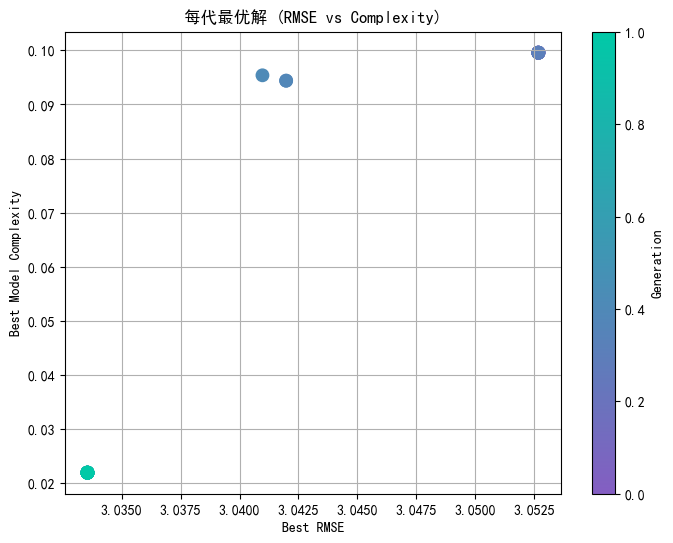

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 提取每一代的最优 (RMSE, Complexity)
best_rmses = []
best_complexities = []

for fit_gen in history_fitness:
    best_rmse, best_complexity = min(fit_gen, key=lambda x: x[0])
    best_rmses.append(best_rmse)
    best_complexities.append(best_complexity)

gens = len(best_rmses)
colors = np.linspace(0, 1, gens)

# 自定义颜色渐变：从 #845EC2 到 #00C9A7
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", ['#845EC2', '#00C9A7'])

# 画图
plt.figure(figsize=(8, 6))
sc = plt.scatter(best_rmses, best_complexities, c=colors, cmap=custom_cmap, s=80)

# colorbar 显示代数
cbar = plt.colorbar(sc)
cbar.set_label('Generation')

plt.xlabel('Best RMSE')
plt.ylabel('Best Model Complexity')
plt.title('每代最优解 (RMSE vs Complexity)')
plt.grid(True)
plt.show()


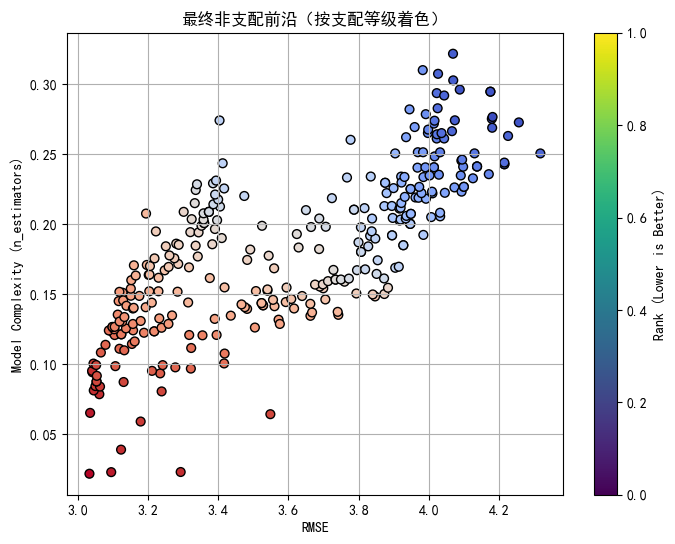

In [34]:
# 评估最后一代种群
final_fitness = evaluate_population(population)

# 非支配排序得到 rank 信息
final_fronts = non_dominated_sort(final_fitness)
rank_map = {}  # 每个个体的 rank
for rank, front in enumerate(final_fronts):
    for idx in front:
        rank_map[idx] = rank

# 获取目标值和对应rank
obj1 = []
obj2 = []
ranks = []
for idx, (rmse, complexity) in enumerate(final_fitness):
    obj1.append(rmse)
    obj2.append(complexity)
    ranks.append(rank_map[idx])

# 将 rank 转换为颜色（越小越橙，越大越蓝）
norm_ranks = np.array(ranks) / max(ranks)  # 归一化到 [0,1]
colors = cm.coolwarm_r(norm_ranks)  # coolwarm_r 是蓝到红渐变

# 绘图
plt.figure(figsize=(8, 6))
scatter = plt.scatter(obj1, obj2, c=colors, s=40, edgecolors='k')
plt.xlabel("RMSE")
plt.ylabel("Model Complexity")
plt.title("最终非支配前沿（按支配等级着色）")
plt.grid(True)
plt.colorbar(scatter, label='Rank (Lower is Better)')
plt.show()